<a href="https://colab.research.google.com/github/TomaszPasnikowski/ML_2026_homeworks/blob/main/LAB10_Homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Homework Assignment – Adversarial Examples**

In this assignment, you will explore how small (invisible to humans) changes to real digits can _fool_ the CNN into misclassifying them, even though the changes are imperceptible to humans.



## Task 1 – CNN Dreams: Last Homework Assignment Revisited

Re-run the input optimization process (for NN dreams) from the previous MLP-class homework assignment, but this time using the **LeNet-5 CNN model** we trained in this class.


1. Starting from ten random noise images, optimize the input so that each image is classified with high confidence as one of the digits 0 through 9.
2. Include an **L2 penalty** on the input to keep the images visually closer to realistic digits. Use a range of penalty strengths (e.g., $\lambda_{l2}$ = 0, and then 0.01 through 10.0).
3. Compare the generated images (with and without L2 penalty) to those generated by the MLP:
   - Are they more or less readable?
   - Do they resemble real MNIST digits more closely or less?
   - Why do you think that happens? Consider the CNN’s inductive biases and architectural properties.

Use `cross_entropy_loss + lambda_l2 * input.pow(2).mean()` as your objective.

Reuse your code: visualize confidence evolution during optimization and generate image grids and (optionally) animations showing how the inputs evolve.


## Task 2 – Adversarial Examples: Fooling LeNet-5

This is the core focus of the assignment.

Using a batch of **real MNIST digits** (e.g., nine examples per class), craft **adversarial examples** by adding subtle, trained noise to the input images. Your goal is to:

- **Keep the human-perceived digit the same** (e.g., a "7" should still look like a "7"),
- But **cause LeNet-5 to misclassify it** – as every other class different from the original, hence nine examples per class.

### Objective
For each image $x$ and its true label $y$, learn a perturbation $\delta$ such that:

- $\text{LeNet5}(x + \delta) = y_{\text{wrong}} $,
- and $ \|\delta\|_2 $ is as small as possible (penalize large perturbations), to keep $x + \delta$ *look* like $x$ for humans.

### Optimization
Use gradient-based optimization on $\delta$ (the noise), while keeping the network weights frozen. Your loss might look like:

```
loss = cross_entropy(model(x + delta), target_wrong_class) +
       lambda_l2 * delta.pow(2).mean()
```

Tune the $\lambda_{l2}$ to find the best range.

### Deliverables for the Second Task
- Select some best examples, showing the original digit and its (correct) classification and the perturbed digit (hopefully, still looking the same to humans) and how it gets misclassified. Show them side by side.
- Report:
  - Success rate of attacks (it doesn't need to be very formal),
  - Effect of $\lambda_{l2}$ on visibility of the noise and success of misclassification,
  - Example image grids and confidence plots.



## Deliverables for the Homework Assignment
- A Google Colab notebook with:
  - Complete implementation for both tasks.
  - Visualizations and animations (animations are optional but encouraged).
  - Clear written analysis of your findings.
- Upload the notebook and results to your GitHub repository for the course.
- Include a link to the notebook and video (if applicable) in the `README.md`.
- In the notebook, include “Open in Colab” badge so it can be launched directly.

## The initial model (from labs)

In [11]:
import torch
import torchvision
from matplotlib import pyplot

transform = torchvision.transforms.Compose(
    [ torchvision.transforms.ToTensor(), #Converts a PIL Image or numpy.ndarray (H x W x C) in the range [0, 255] to a torch.FloatTensor of shape (C x H x W) in the range [0.0, 1.0]
      torchvision.transforms.Normalize((0.1307), (0.3081))])

trainset = torchvision.datasets.MNIST(root='./data',
                                      train=True,
                                      download=True,
                                      transform=transform)

trainloader = torch.utils.data.DataLoader(trainset,
                                          batch_size=2048,
                                          shuffle=True)   #we do shuffle it to give more randomizations to training epochs

testset = torchvision.datasets.MNIST(root='./data',
                                     train=False,
                                     download=True,
                                     transform=transform)

testloader = torch.utils.data.DataLoader(testset,
                                         batch_size=1,
                                         shuffle=False)

In [12]:
import torch.nn as nn
import torch.nn.functional as F

class LeNet5(torch.nn.Module):
    def __init__(self):
        super().__init__()

        # TODO: add missing layers

        self.conv1 = nn.Conv2d(in_channels= 1, out_channels= 6, kernel_size= 5, padding= 2, stride= 1)
        self.conv2 = nn.Conv2d(in_channels= 6, out_channels= 16, kernel_size= 5, padding= 0, stride= 1)
        self.linear1 = nn.Linear(in_features= 16*5*5, out_features= 120)
        self.linear2 = nn.Linear(in_features= 120, out_features= 80)
        self.linear3 = nn.Linear(in_features= 80, out_features= 10)

        self.pool = nn.AvgPool2d(kernel_size= 2, stride= 2)
        #self.relu = nn.ReLU()
        self.flatten = nn.Flatten()

        self.dropout = torch.nn.Dropout(0.05)

    def forward(self, x): # B x 1 x 28 x 28
        # TODO: add missing processing
        x = self.conv1(x)     # B x 6 x 28 x 28
        x = F.relu(x)
        x = self.pool(x)      # B x 6 x 14 x 14

        x = self.conv2(x)     # B x 16 x 10 x 10
        x = F.relu(x)
        x = self.pool(x)      # B x 16 x 5 x 5

        #x = self.flatten(x)
        x = x.view(x.size(0), -1)# B x 400

        x = self.linear1(x)   # B x 120
        x = F.relu(x)

        x = self.linear2(x)   # B x 80
        x = F.relu(x)

        x = self.linear3(x)   # B x 10

        x = self.dropout(x)

        return x

In [13]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Working on {device}")

net = LeNet5().to(device)
optimizer = torch.optim.Adam(net.parameters(), 0.001)   #initial and fixed learning rate of 0.001.

net.train()    #it notifies the network layers (especially batchnorm or dropout layers, which we don't use in this example) that we are doing traning
for epoch in range(16):  #  an epoch is a training run through the whole data set

    for batch, data in enumerate(trainloader):
        batch_inputs, batch_labels = data

        batch_inputs = batch_inputs.to(device)  #explicitly moving the data to the target device
        batch_labels = batch_labels.to(device)

        optimizer.zero_grad()

        batch_outputs = net(batch_inputs)   #this line calls the forward(self, x) method of the LeNet5 object. Please note,
                                            # the nonlinear activation after the last layer is NOT applied
        loss = torch.nn.functional.cross_entropy(batch_outputs, batch_labels, reduction = "mean") #instead, nonlinear softmax is applied internally in THIS loss function
        print("epoch:", epoch, "batch:", batch, "current batch loss:", loss.item())
        loss.backward()       #this computes gradients as we have seen in previous workshops
        optimizer.step()     #but this line in fact updates our neural network.
                                ####You can experiment - comment this line and check, that the loss DOE

Working on cuda
epoch: 0 batch: 0 current batch loss: 2.3072404861450195
epoch: 0 batch: 1 current batch loss: 2.294022560119629
epoch: 0 batch: 2 current batch loss: 2.282428741455078
epoch: 0 batch: 3 current batch loss: 2.2693681716918945
epoch: 0 batch: 4 current batch loss: 2.2513654232025146
epoch: 0 batch: 5 current batch loss: 2.23262357711792
epoch: 0 batch: 6 current batch loss: 2.2087721824645996
epoch: 0 batch: 7 current batch loss: 2.1852855682373047
epoch: 0 batch: 8 current batch loss: 2.1532862186431885
epoch: 0 batch: 9 current batch loss: 2.120664358139038
epoch: 0 batch: 10 current batch loss: 2.071532726287842
epoch: 0 batch: 11 current batch loss: 2.0194125175476074
epoch: 0 batch: 12 current batch loss: 1.9790098667144775
epoch: 0 batch: 13 current batch loss: 1.9193243980407715
epoch: 0 batch: 14 current batch loss: 1.8357207775115967
epoch: 0 batch: 15 current batch loss: 1.7630032300949097
epoch: 0 batch: 16 current batch loss: 1.6741747856140137
epoch: 0 batch

## Task 1

In [14]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

def show_dreams(dream_images, certainty, l):
  """
  A function to plot the dream images.
  """
  fig = plt.figure(figsize=(14, 6))
  fig.suptitle(f"$\lambda$ = {l}")
  gs = GridSpec(2, 6, width_ratios=[1,1,1,1,1,2], wspace=0.3, hspace=0.3)
  for n in range(10):
    i = n // 5
    j = n % 5
    #ax = axs[i][j]
    ax = fig.add_subplot(gs[i, j])
    ax.imshow(dream_images[n].detach().cpu().squeeze(), cmap='gray')
    ax.set_title(n)
    ax.axis('off')
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

  ax_curve = fig.add_subplot(gs[:, 5])
  ax_curve.plot(certainty, linewidth=2)
  ax_curve.set_title("Average Certainty Evolution")
  ax_curve.set_xlabel("Optimization Step")
  ax_curve.set_ylim(0, 1)
  ax_curve.grid(True)
  plt.show()


<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1464/299130842.py:9: SyntaxWarning: invalid escape sequence '\l'
  fig.suptitle(f"$\lambda$ = {l}")


In [15]:
# freezing the network
net.eval()
for param in net.parameters():
    param.requires_grad = False


lambda_l2 = 0


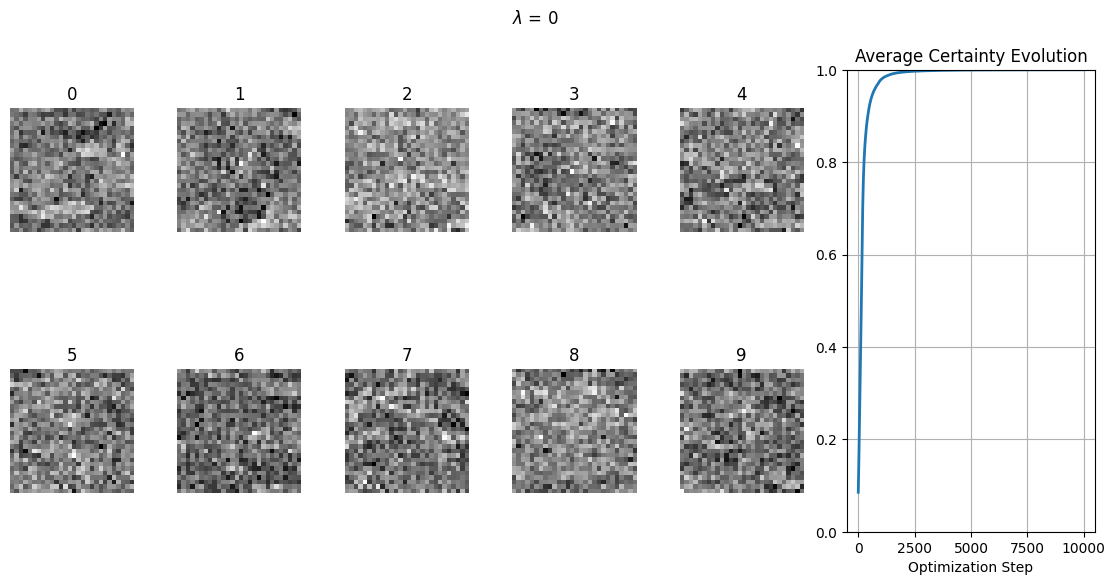

lambda_l2 = 0 | epoch 9999 | loss: 0.0000 | pixel range: [-4.1044, 4.0074]
lambda_l2 = 0.01


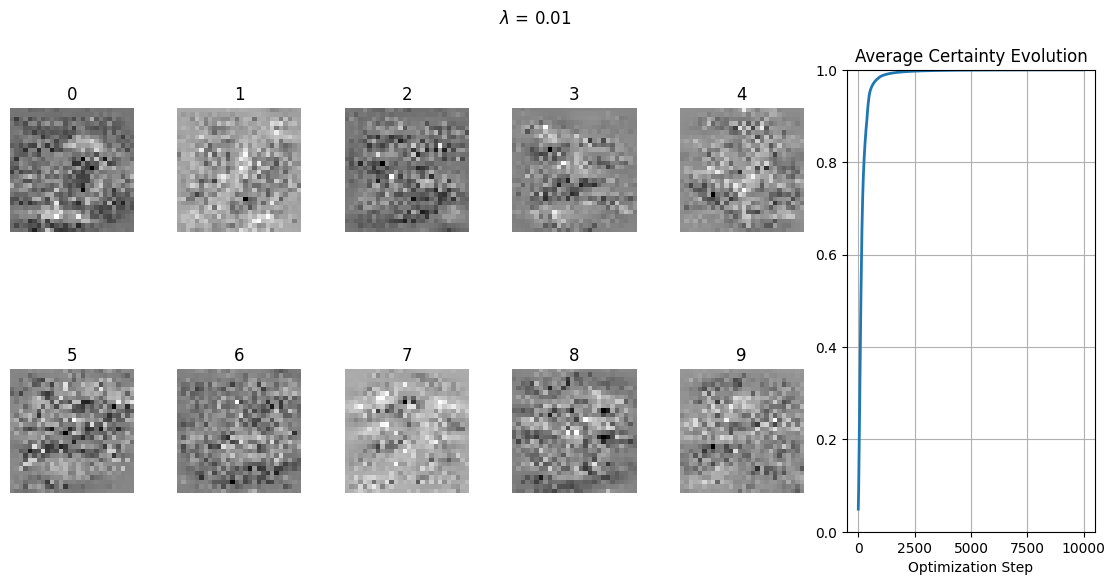

lambda_l2 = 0.01 | epoch 9999 | loss: 0.0041 | pixel range: [-3.7075, 3.1517]
lambda_l2 = 0.1


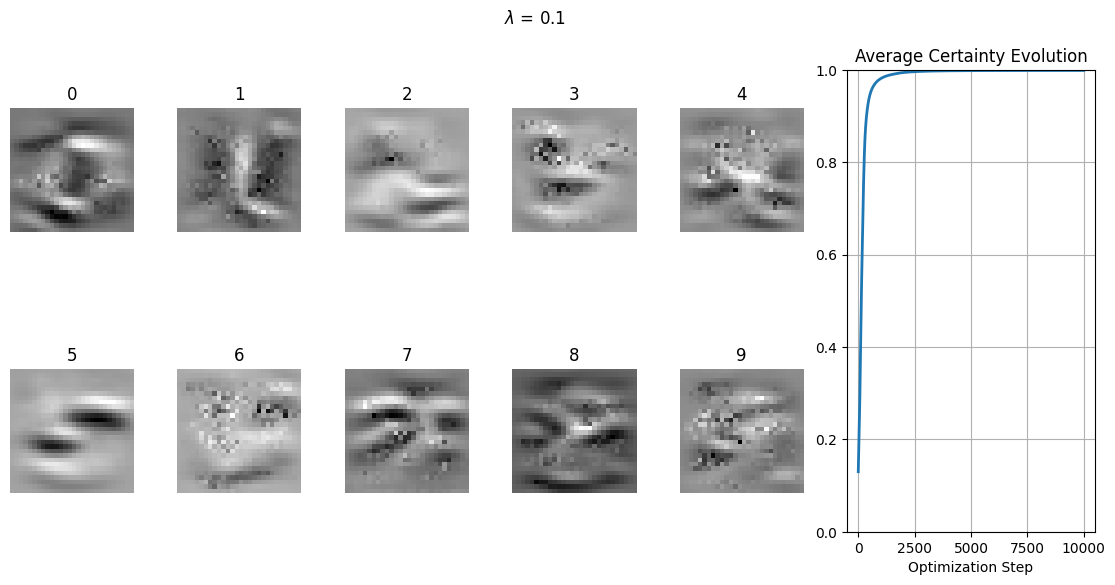

lambda_l2 = 0.1 | epoch 9999 | loss: 0.0082 | pixel range: [-1.5801, 1.3240]
lambda_l2 = 1


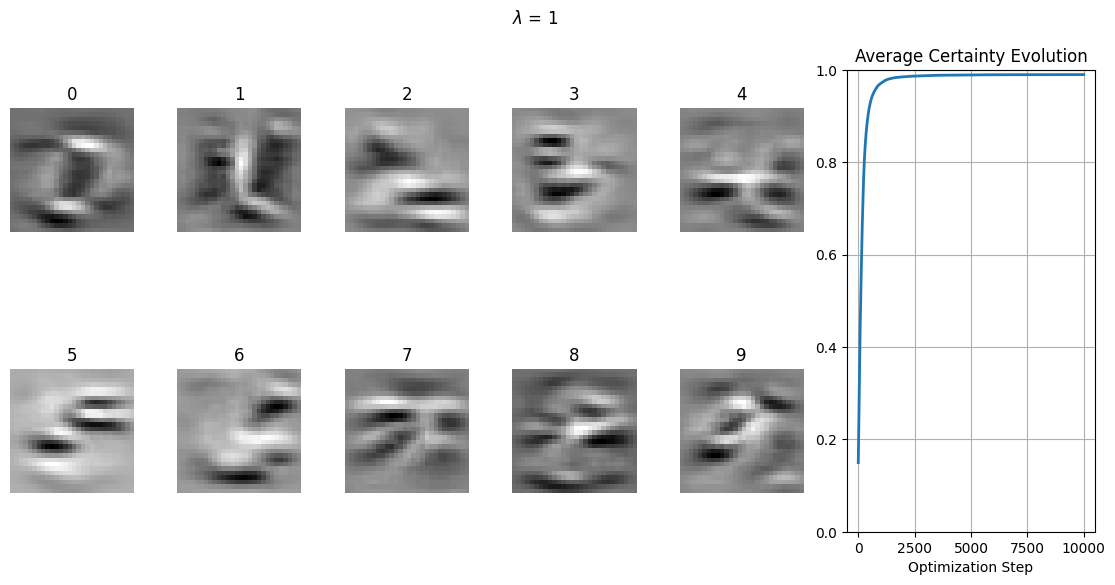

lambda_l2 = 1 | epoch 9999 | loss: 0.0396 | pixel range: [-0.6974, 0.8955]
lambda_l2 = 10


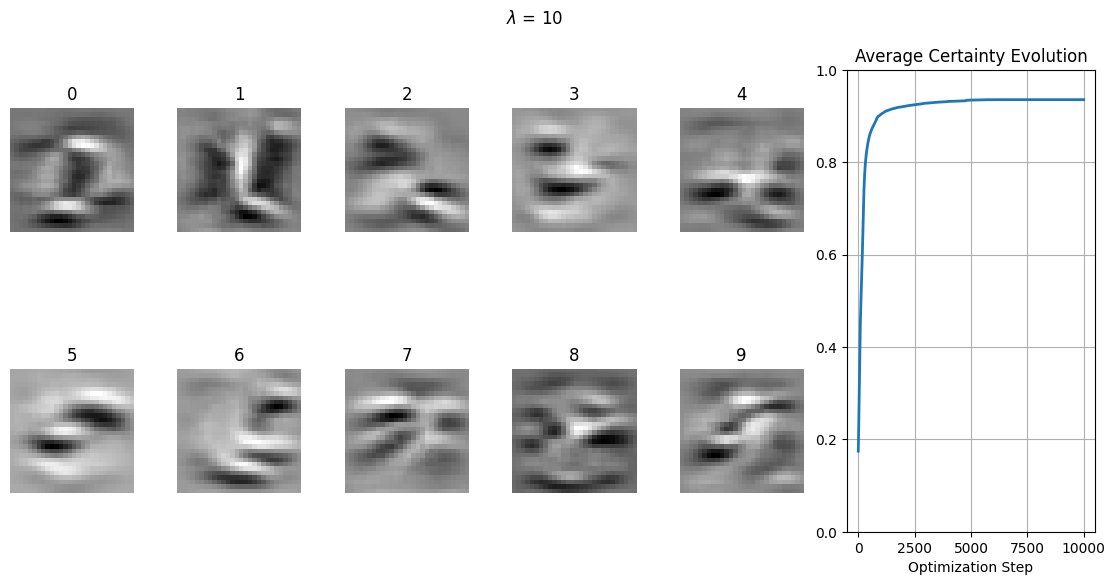

lambda_l2 = 10 | epoch 9999 | loss: 0.1931 | pixel range: [-0.4524, 0.5051]


In [18]:
for lambda_l2 in [0, 0.01, 0.1, 1, 10]:
  print(f"lambda_l2 = {lambda_l2}")

  dream_images = torch.randn(10, 1, 28, 28, device=device, requires_grad=True)
  targets = torch.arange(10).to(device)
  optimizer = torch.optim.Adam([dream_images], 0.001)
  certainty = list()

  for epoch in range(10000):
      optimizer.zero_grad()

      outputs = net(dream_images)
      certainty.append(torch.softmax(outputs, dim= 1).diag().mean().detach().cpu()) # getting the average certainty of the correct target
      ce_loss = torch.nn.functional.cross_entropy(outputs, targets)
      l2_loss = lambda_l2 * dream_images.pow(2).mean()

      loss  = ce_loss + l2_loss
      loss.backward()
      optimizer.step()

      if epoch == 9999:
          show_dreams(dream_images, certainty, lambda_l2)
          imgs = dream_images.detach().cpu()
          print(f"lambda_l2 = {lambda_l2} | epoch {epoch} | loss: {loss.item():.4f} | pixel range: [{imgs.min():.4f}, {imgs.max():.4f}]")

Compared to the approach using simple MLP, these generated digits are less grainy. The background is usually more plain and every image posesses some of the characteristics of the relevant digit (such as loops, curves, straight lines). The results are still not ideal as sometimes these characteristics do not form a consistent picture but rather look like many instances of the same digits drawn at once. As previously, larger $\lambda$ means worse certainty but usually more human-readable results.

The difference between CNN and MLP approach in this task comes down to the fact that a simple perceptron network works on the pixels one-by-one, whereas a convolutional network uses kernels, which inspect the image in certain windows. A CNN approach has therefore an ability to work more globally, recognizing shapes and patterns more efficiently.

## Task 2

In [19]:
def show_adversarial(imgs):
  """
  A function to plot the adversarial examples.
  """
  fig, axs= pyplot.subplots(10, 9)
  for n in range(90):
    i = n // 9
    j = n % 9

    ax = axs[i][j]
    ax.imshow(imgs[n].detach().cpu().squeeze(), cmap='gray')
    ax.axis('off')

  pyplot.show()


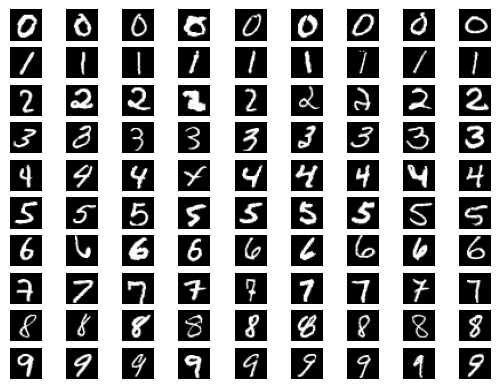

In [20]:
# preparation of the dataset of 90 images (9 for each digit) and their false labels

for i, l in trainloader:
  images, labels= i, l
  break

samples = {i : images[labels == i][:9] for i in range(10)}

batch_images = torch.cat(list(samples.values()), dim=0).to(device)
batch_labels = list()
for i in range(10):
  batch_labels += [x for x in range(10) if x != i]

batch_labels = torch.tensor(batch_labels).to(device)

show_adversarial(batch_images)


lambda_l2 = 0.01


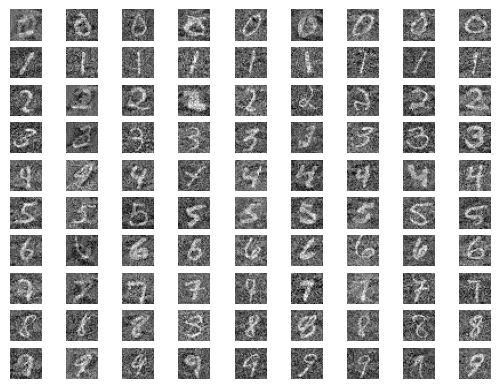

lambda_l2 = 0.01 | epoch 999 | loss: 0.0122 | accuracy: 0.00 | fool accuracy: 1.00
lambda_l2 = 0.1


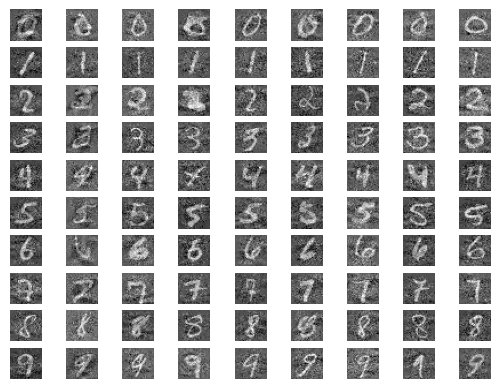

lambda_l2 = 0.1 | epoch 999 | loss: 0.0681 | accuracy: 0.00 | fool accuracy: 1.00
lambda_l2 = 1


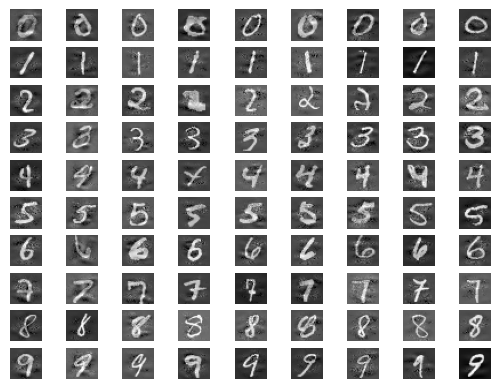

lambda_l2 = 1 | epoch 999 | loss: 0.1688 | accuracy: 0.00 | fool accuracy: 1.00
lambda_l2 = 10


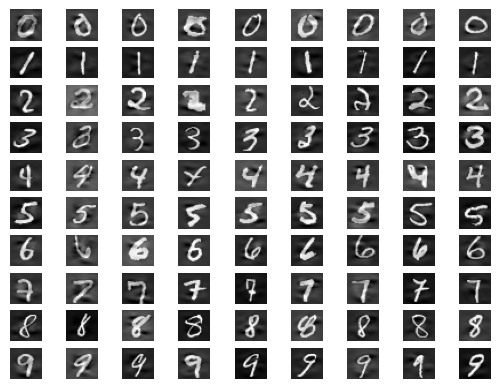

lambda_l2 = 10 | epoch 999 | loss: 0.8759 | accuracy: 0.00 | fool accuracy: 1.00
lambda_l2 = 100


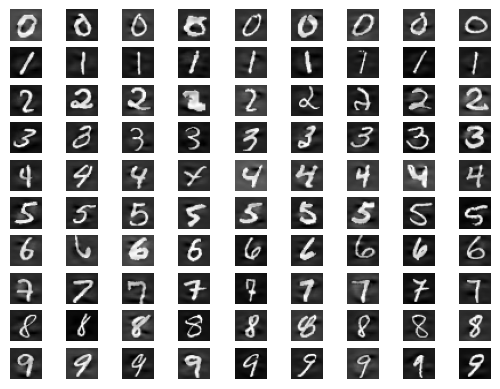

lambda_l2 = 100 | epoch 999 | loss: 5.7128 | accuracy: 0.41 | fool accuracy: 0.54


In [21]:
for lambda_l2 in [0.01, 0.1, 1, 10, 100]:
  print(f"lambda_l2 = {lambda_l2}")
  noise = torch.randn(90, 1, 28, 28, device=device, requires_grad=True)
  targets = batch_labels
  optimizer = torch.optim.Adam([noise], 0.01)

  for epoch in range(1000):
      optimizer.zero_grad()

      outputs = net(batch_images + noise)
      ce_loss = torch.nn.functional.cross_entropy(outputs, targets)
      l2_loss = lambda_l2 * noise.pow(2).mean()

      loss  = ce_loss + l2_loss
      loss.backward()
      optimizer.step()

      if epoch == 999:
          show_adversarial(batch_images + noise)
          accuracy = ((outputs.argmax(axis= 1).cpu() == torch.arange(10).repeat_interleave(9)) * 1.0).mean()
          fool_accuracy = ((outputs.argmax(axis= 1).cpu() == batch_labels.detach().cpu()) * 1.0).mean()

          print(f"lambda_l2 = {lambda_l2} | epoch {epoch} | loss: {loss.item():.4f} | accuracy: {accuracy:.2f} | fool accuracy: {fool_accuracy:.2f}")

Two types of accuracy measures were introduced:
- plain accuracy - how well does the network identify the ground truth labels
- "fool accuracy" - how well does the network identify the fake labels we introduced

So achieving the initial goal to fool the network means obtaining low plain accuracy. Moreover high "fool accuracy" means that we were able to force the model into misclassifing the digits exactly the way we wanted.

The empirical results show clearly that for greater penalties the noised digits are indistinguishable from the real ones but the network predicts the ground truth quite often.  It is perfectly logical as greater penalty means less space for modifying the input.

For lower $\lambda$ however, the images are noisy (although one can usually recognize the initial digit) but the network is unable to categorize them correctly.

In summary the loss will be greater for bigger penalty but the modified images will resemble the ground truth more. The results suggest that the attacks were successful as for $\lambda = 10$ the noised images look very clear to a human eye but the network has misclassified all of them by assigning them exactly the same labels it was forced to.